# Heart Attack Prediction – Classification Algorithms
Comparing **Naive Bayes**, **Decision Tree**, **KNN**, and **ANN (MLP)** on the Heart Attack dataset.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

## 2. Load Dataset

In [2]:
df = pd.read_csv("Heart_Attack.csv")
df.head()

,age,gender,impluse,pressurehight,pressurelow,glucose,kcm,troponin,class
0,64,1,66,160,83,160.0,1.80,0.012,negative
1,21,1,94,98,46,296.0,6.75,1.060,positive
2,55,1,64,160,77,270.0,1.99,0.003,negative
3,64,1,70,120,55,270.0,13.87,0.122,positive
4,55,1,64,112,65,300.0,1.08,0.003,negative


## 3. Basic Info

In [3]:
print("Shape:", df.shape)
df.info()

Shape: (1319, 9)
<class 'pandas.DataFrame'>
RangeIndex: 1319 entries, 0 to 1318
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   age            1319 non-null   int64  
 1   gender         1319 non-null   int64  
 2   impluse        1319 non-null   int64  
 3   pressurehight  1319 non-null   int64  
 4   pressurelow    1319 non-null   int64  
 5   glucose        1319 non-null   float64
 6   kcm            1319 non-null   float64
 7   troponin       1319 non-null   float64
 8   class          1319 non-null   str    
dtypes: float64(3), int64(5), str(1)
memory usage: 92.9 KB


## 4. Missing Values

In [4]:
df.isnull().sum()

age              0
gender           0
impluse          0
pressurehight    0
pressurelow      0
glucose          0
kcm              0
troponin         0
class            0
dtype: int64

## 5. Target Distribution

class
positive    810
negative    509
Name: count, dtype: int64


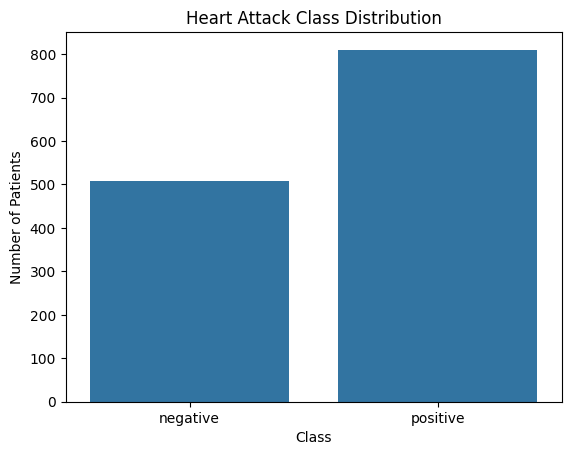

In [5]:
print(df["class"].value_counts())

sns.countplot(x="class", data=df)
plt.title("Heart Attack Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Patients")
plt.show()

## 6. Features and Target

In [6]:
X = df.drop("class", axis=1)
y = df["class"].map({"negative": 0, "positive": 1})
print(y.value_counts())

class
1    810
0    509
Name: count, dtype: int64


## 7. Train-Test Split (80/20)

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (1055, 8)  Test: (264, 8)


## 8. Feature Scaling (needed for KNN and ANN)

In [8]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 9. Helper Function for Evaluation

In [9]:
def evaluate(name, y_test, y_pred):
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    print(f"{name}")
    print("-" * len(name))
    print("Accuracy :", acc)
    print("Precision:", prec)
    print("Recall   :", rec)
    print("F1 Score :", f1)
    print()

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Negative", "Positive"],
                yticklabels=["Negative", "Positive"])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"{name} Confusion Matrix")
    plt.show()

    return [name, acc, prec, rec, f1]

## 10. Naive Bayes

Naive Bayes
-----------
Accuracy : 0.696969696969697
Precision: 0.9880952380952381
Recall   : 0.5123456790123457
F1 Score : 0.6747967479674797



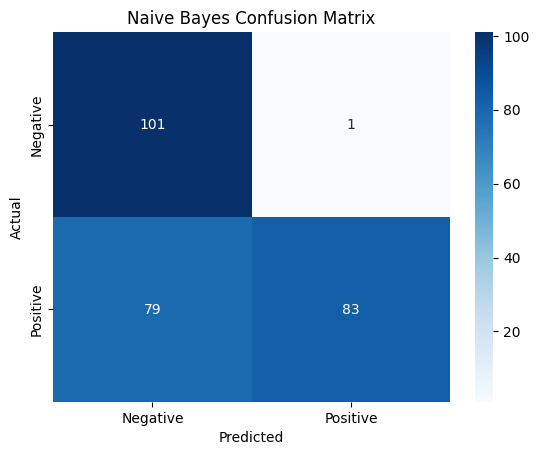

In [10]:
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)
row_nb = evaluate("Naive Bayes", y_test, y_pred_nb)

## 11. Decision Tree

Decision Tree
-------------
Accuracy : 0.9810606060606061
Precision: 0.9815950920245399
Recall   : 0.9876543209876543
F1 Score : 0.9846153846153847



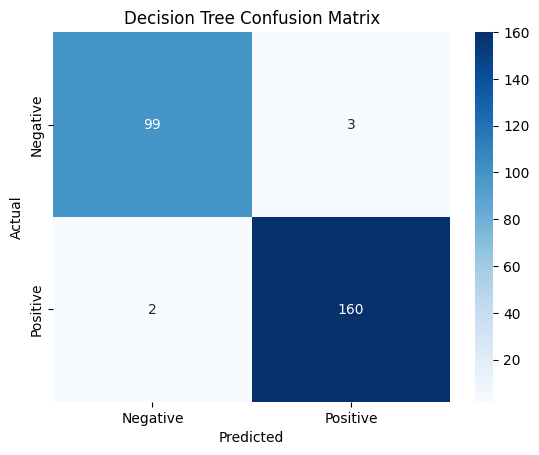

In [11]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)
row_dt = evaluate("Decision Tree", y_test, y_pred_dt)

## 12. K-Nearest Neighbors (KNN)

KNN
---
Accuracy : 0.6666666666666666
Precision: 0.7534246575342466
Recall   : 0.6790123456790124
F1 Score : 0.7142857142857143



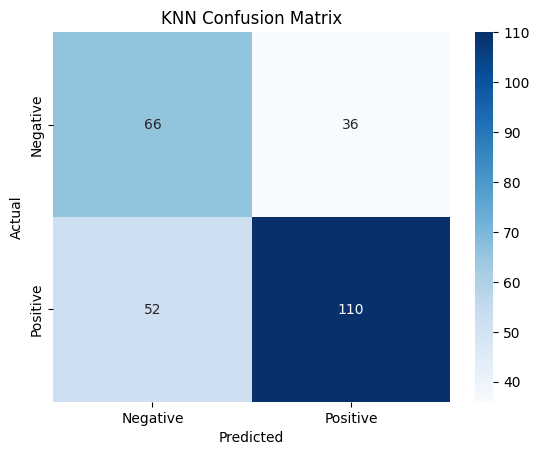

In [12]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)
y_pred_knn = knn_model.predict(X_test_scaled)
row_knn = evaluate("KNN", y_test, y_pred_knn)

## 13. Artificial Neural Network (ANN / MLP)

ANN
---
Accuracy : 0.875
Precision: 0.9215686274509803
Recall   : 0.8703703703703703
F1 Score : 0.8952380952380953



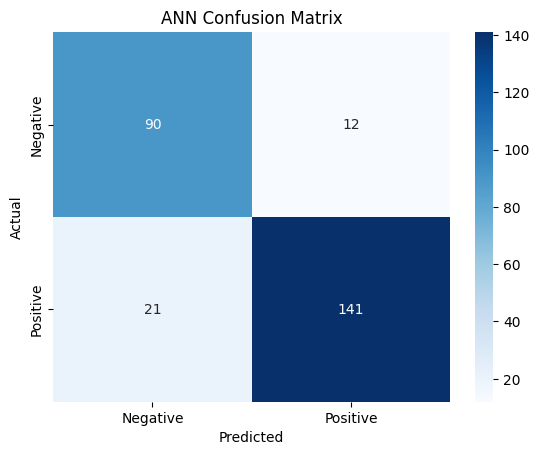

In [13]:
ann_model = MLPClassifier(
    hidden_layer_sizes=(16, 8),
    activation="relu",
    solver="adam",
    max_iter=1000,
    random_state=42
)
ann_model.fit(X_train_scaled, y_train)
y_pred_ann = ann_model.predict(X_test_scaled)
row_ann = evaluate("ANN", y_test, y_pred_ann)

## 14. Compare All Models

In [14]:
results = pd.DataFrame(
    [row_nb, row_dt, row_knn, row_ann],
    columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score"]
)
results

,Model,Accuracy,Precision,Recall,F1 Score
0,Naive Bayes,0.696970,0.988095,0.512346,0.674797
1,Decision Tree,0.981061,0.981595,0.987654,0.984615
2,KNN,0.666667,0.753425,0.679012,0.714286
3,ANN,0.875000,0.921569,0.870370,0.895238


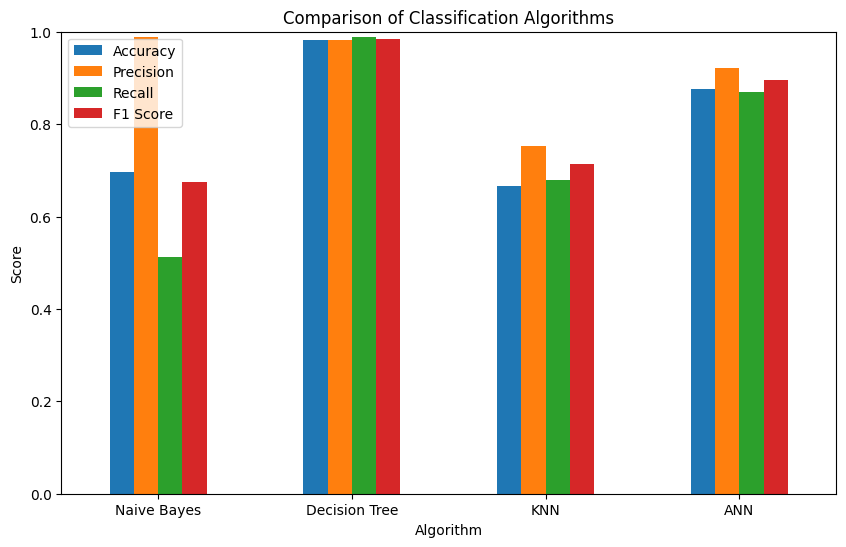

In [15]:
results.set_index("Model").plot(kind="bar", figsize=(10, 6))
plt.title("Comparison of Classification Algorithms")
plt.ylabel("Score")
plt.xlabel("Algorithm")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend()
plt.show()

## 15. Best Model

In [16]:
best_model = results.loc[results["F1 Score"].idxmax()]
print("Best Model:")
print(best_model)

Best Model:
Model        Decision Tree
Accuracy          0.981061
Precision         0.981595
Recall            0.987654
F1 Score          0.984615
Name: 1, dtype: object
